In [33]:
import time
import re
import pandas as pd
import numpy as np
from openpyxl import Workbook
import threading
# import selenium as sl
from selenium import webdriver
from selenium.webdriver.firefox.options import Options
from selenium.webdriver.support.wait import WebDriverWait
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.common.by import By

In [34]:
OUTPUT_DIR      = 'output'
URL             = "https://hh.ru/"
REQUEST_TEXT    = ["Тестировщик"]

In [35]:
# Возвращает текст одиночного элемента при поиске по XPATH
def get_element_text_by_xpath(driver, xpath):
    try:
        text_area = driver.find_element(By.XPATH, xpath).text
    except Exception as e:
        text_area = "Not found"

    return text_area

In [36]:
def get_skills(driver):
    try:
        result_list = []
        text_area = driver.find_elements(By.XPATH, "//li[@data-qa='skills-element']")
        for text in text_area:
            result_list.append(str(text.text))
    except Exception as e:
        result_list = ["Not found"]
    
    return result_list

In [37]:
def get_vacancy_name(driver):
    return get_element_text_by_xpath(driver, "//h1[@data-qa='vacancy-title']")

In [38]:
def get_company_name(driver):
    #return get_element_text_by_xpath(driver, "//a[@data-qa='vacancy-company-name']") # Не прогружается при новом подключении
    return driver.find_elements(By.CLASS_NAME, "vacancy-company-name")[1].text

In [39]:
def get_vacancy_experience(driver):
    vacancy_experience = get_element_text_by_xpath(driver, "//span[@data-qa='vacancy-experience']")
    vacancy_experience = vacancy_experience.split(": ")[-1]
    return vacancy_experience

In [40]:
def get_work_schedule_by_days(driver): 
    work_schedule_by_days = get_element_text_by_xpath(driver, "//p[@data-qa='work-schedule-by-days-text']")
    work_schedule_by_days = work_schedule_by_days.split(": ")[-1]
    return work_schedule_by_days

In [41]:
def get_working_hours(driver):
    working_hours = get_element_text_by_xpath(driver, "//div[@data-qa='working-hours-text']")
    working_hours = working_hours.split(": ")[-1]
    return working_hours

In [42]:
def get_work_formats(driver):
    work_formats = get_element_text_by_xpath(driver, "//p[@data-qa='work-formats-text']")
    work_formats = work_formats.split(": ")[-1]
    return work_formats

In [43]:
def get_company_link(driver):
    try:
        text_area = driver.find_element(By.XPATH, "//a[@data-qa='vacancy-company-name']")
        link = text_area.get_attribute('href')
    except Exception as e:
        link = "Not found"
    
    return link

In [44]:
def parse_vacancy_page(driver):
    dict_return = {}
    dict_return["Наименование вакансии"]    = get_vacancy_name(driver)
    dict_return["Наименование компании"]    = get_company_name(driver)
    dict_return["Ссылка на компанию"]       = get_company_link(driver)
    dict_return["Опыт работы"]              = get_vacancy_experience(driver)
    dict_return["График"]                   = get_work_schedule_by_days(driver)
    dict_return["Рабочие часы"]             = get_working_hours(driver)
    dict_return["Формат работы"]            = get_work_formats(driver)
    dict_return["Ключевые навыки"]          = get_skills(driver)
    
    return dict_return

In [45]:
# Опции браузера
firefox_options = Options()
firefox_options.add_argument("--headless")
firefox_options.add_argument("--incognito")

### Парсинг страниц

In [46]:
def set_request(driver, text):
    # В главном меню ищем вакансии по запросу
    input_form = driver.find_element(By.ID, "a11y-search-input")
    input_form.send_keys(text)  
    input_form.send_keys(Keys.ENTER)

    # Отключаем блок регистрации
    try:
        exit_btn = driver.find_element(By.CLASS_NAME, "bloko-modal-close-button")
        exit_btn.click()
    except Exception:
        print("Без блока регистрации")

In [47]:
def get_max_page_num(driver):
    max_page = 0
    webdr_pages_num = driver.find_elements(By.XPATH, "//a[@data-qa='pager-page']")
    for page_num in webdr_pages_num:
        if int(page_num.text) > max_page:
            max_page = int(page_num.text)
    return max_page

In [48]:
# Смена шаблона URL главного запроса на постраничный
def get_temp_url(driver):
    webdr_pages_num = driver.find_elements(By.XPATH, "//a[@data-qa='pager-page']")
    driver.execute_script("arguments[0].click();", webdr_pages_num[1])
    time.sleep(2)
    driver.execute_script("arguments[0].click();", webdr_pages_num[0])
    temp_link = driver.current_url
    return temp_link

In [49]:
def run_page(temp_link, max_page_num, set_links):
    for page_num in range(max_page_num):
        page_driver = webdriver.Firefox(options=firefox_options)
        page_link = re.sub(r"page=[0-9]+", f"page={page_num}", temp_link)
        page_driver.get(page_link)

        # Список ссылок на вакансии на странице
        header_links = page_driver.find_elements(By.XPATH, "//a[@data-qa='serp-item__title']")
        #print(len(header_links))

        # Сохраняем ссылки
        for header_link in header_links[:]:
            link = header_link.get_attribute('href')
            set_links.add(link)

        page_driver.quit()
        print(f"{(page_num + 1) * 100 / (max_page_num):.{2}f}% done; current_link: {page_link}")        

In [50]:
# Формирования массива ссылок на вакансии
set_header_link = set()

try:    
    # Выполняет поиск по каждому запросу для выявления множества ссылок на вакансии
    for req_text in REQUEST_TEXT:
        driver = webdriver.Firefox(options=firefox_options)
        driver.get(URL)
        set_request(driver, req_text)
        # Находим максимальное кол-во страниц по запросу
        max_page_num = get_max_page_num(driver)

        # Кликаем для смены шаблона URL и получения searchSessionId (Костыль)
        temp_link = get_temp_url(driver)
        
        # Проходим каждую страницу по шаблону
        run_page(temp_link, max_page_num, set_header_link)

        driver.quit()
except Exception as error:
    print('\n\n\n---------\n\n\n')
    print(error)

11.11% done; current_link: https://spb.hh.ru/vacancies/testirovshik?page=0&searchSessionId=de68fa65-0e24-4496-a027-7e8ce168f6b0
22.22% done; current_link: https://spb.hh.ru/vacancies/testirovshik?page=1&searchSessionId=de68fa65-0e24-4496-a027-7e8ce168f6b0
33.33% done; current_link: https://spb.hh.ru/vacancies/testirovshik?page=2&searchSessionId=de68fa65-0e24-4496-a027-7e8ce168f6b0
44.44% done; current_link: https://spb.hh.ru/vacancies/testirovshik?page=3&searchSessionId=de68fa65-0e24-4496-a027-7e8ce168f6b0
55.56% done; current_link: https://spb.hh.ru/vacancies/testirovshik?page=4&searchSessionId=de68fa65-0e24-4496-a027-7e8ce168f6b0
66.67% done; current_link: https://spb.hh.ru/vacancies/testirovshik?page=5&searchSessionId=de68fa65-0e24-4496-a027-7e8ce168f6b0
77.78% done; current_link: https://spb.hh.ru/vacancies/testirovshik?page=6&searchSessionId=de68fa65-0e24-4496-a027-7e8ce168f6b0
88.89% done; current_link: https://spb.hh.ru/vacancies/testirovshik?page=7&searchSessionId=de68fa65-0e24

In [51]:
# Убираем qury в запросе
set_links = set()
for link in set_header_link:
    if '?' in link:
        curr_link, query = link.split('?')
        set_links.add(curr_link)

print(f"Кол-во: {len(set_links)}")
set_links

Кол-во: 434


{'https://spb.hh.ru/vacancy/100819442',
 'https://spb.hh.ru/vacancy/107159101',
 'https://spb.hh.ru/vacancy/107661505',
 'https://spb.hh.ru/vacancy/107661658',
 'https://spb.hh.ru/vacancy/107662464',
 'https://spb.hh.ru/vacancy/107807626',
 'https://spb.hh.ru/vacancy/107923677',
 'https://spb.hh.ru/vacancy/108376264',
 'https://spb.hh.ru/vacancy/108376266',
 'https://spb.hh.ru/vacancy/108806806',
 'https://spb.hh.ru/vacancy/109239766',
 'https://spb.hh.ru/vacancy/109878447',
 'https://spb.hh.ru/vacancy/110861130',
 'https://spb.hh.ru/vacancy/111043652',
 'https://spb.hh.ru/vacancy/111342030',
 'https://spb.hh.ru/vacancy/111900012',
 'https://spb.hh.ru/vacancy/111957168',
 'https://spb.hh.ru/vacancy/112172031',
 'https://spb.hh.ru/vacancy/112321185',
 'https://spb.hh.ru/vacancy/112537653',
 'https://spb.hh.ru/vacancy/112582425',
 'https://spb.hh.ru/vacancy/114813345',
 'https://spb.hh.ru/vacancy/114822448',
 'https://spb.hh.ru/vacancy/115132817',
 'https://spb.hh.ru/vacancy/115602160',


### Парсинг вакансий

In [52]:
lock = threading.Lock()

def parse_vacancy_links(list_links):
    global rows
    global dict_skills
    
    temp_cnt = 0

    for header_link in list_links:
        element_driver = webdriver.Firefox(options=firefox_options)
        element_driver.get(header_link)
        vacancy_info = parse_vacancy_page(element_driver)
        vacancy_info["Ссылка на вакансию"] = header_link

        lock.acquire() # Захватываем блокировку
        try:
            rows.append(vacancy_info)

            # Добавление информации о компетенциях во множество
            for skill in rows[-1].get("Ключевые навыки"):
                if skill not in dict_skills.keys():
                    dict_skills[skill] = 1
                else:
                    dict_skills[skill] += 1

            temp_cnt += 1
        finally:
            lock.release() # Освобождаем блокировку в любом случае
            
        element_driver.quit()  
        print(f"{(temp_cnt) * 100 / (len(list_links)):.{2}f}% done; current_link: {header_link}")

In [ ]:
# Создание результирующих источников
dict_skills = {}
rows = []
n = 10

list_links = list(set_links)
threads     = []
cut_count   = int(len(list_links) / n) + 1
list_links_cut = [list_links[i:i + cut_count] for i in range(0, len(list_links), cut_count)]

for i in range(n):
    thread = threading.Thread(target=parse_vacancy_links, args=(list_links_cut[i],))
    threads.append(thread)
    thread.start()

# Ожидание потоков
for thread in threads:
    thread.join()

In [54]:
df = pd.DataFrame.from_dict(rows, orient='columns')
df["Ключевые навыки"] = df["Ключевые навыки"].apply(lambda x: ";".join(x))
df

,Наименование вакансии,Наименование компании,Ссылка на компанию,Опыт работы,График,Рабочие часы,Формат работы,Ключевые навыки,Ссылка на вакансию
0,Project Manager (IT),idaproject,https://spb.hh.ru/employer/1579449?hhtmFrom=va...,1–3 года,5/2,8,Not found,Управление проектами;Работа в команде;Ведение ...,https://spb.hh.ru/vacancy/121020929
1,Тестировщик ПО (Junior) в область программно-а...,ООО ССГ Навигация,https://spb.hh.ru/employer/11606019?hhtmFrom=v...,не требуется,5/2,8,на месте работодателя,,https://spb.hh.ru/vacancy/121733322
2,IOS-разработчик (swift),ООО НИЦ Аэроскрипт,https://spb.hh.ru/employer/5095483?hhtmFrom=va...,1–3 года,5/2,8,"на месте работодателя, удалённо или гибрид",Swift;MVVM;iOS;Realm;Alamofire;RxSwift;UIKit,https://spb.hh.ru/vacancy/121906359
3,Продавец-кассир (Красногвардейский район),Улыбка радуги,https://spb.hh.ru/employer/40938?hhtmFrom=vacancy,не требуется,"6/1, 5/2, 4/3 и ещё 10","4, 5, 6 и ещё 8",Not found,,https://spb.hh.ru/vacancy/89695905
4,QA Engineer / Тестировщик,Botan Investments,https://spb.hh.ru/employer/5062951?hhtmFrom=va...,1–3 года,5/2,5,удалённо,,https://spb.hh.ru/vacancy/122057468
...,...,...,...,...,...,...,...,...,...
419,Администратор магазина,Улыбка радуги,https://spb.hh.ru/employer/40938?hhtmFrom=vacancy,не требуется,Not found,Not found,на месте работодателя,,https://spb.hh.ru/vacancy/120267072
420,Сервисный инженер по ремонту и обслуживанию сл...,ООО Системы Безопасности,https://spb.hh.ru/employer/1689553?hhtmFrom=va...,не требуется,5/2,8,Not found,Прокладка кабелей;Монтаж оборудования;работа с...,https://spb.hh.ru/vacancy/122383476
421,Тестировщик ПО,Филиал ФКУ Налог-Сервис ФНС России по ЦОД в г....,https://spb.hh.ru/employer/1864933?hhtmFrom=va...,не требуется,5/2,8\nВечерние или ночные смены,на месте работодателя,,https://spb.hh.ru/vacancy/120898595
422,Руководитель проектов,ПАО «Газпром нефть» ИТ,https://spb.hh.ru/employer/39305?dpt=gpn-39305...,3–6 лет,5/2,8,на месте работодателя,PMBOK,https://spb.hh.ru/vacancy/120920380


In [55]:
dict_skills = dict(sorted(dict_skills.items(), key=lambda value: value[1], reverse=True)) # Сортировка по кол-ву
df2 = pd.DataFrame(dict_skills.items(), columns=["Ключевые навыки", "Количество"])
df2

,Ключевые навыки,Количество
0,SQL,49
1,Функциональное тестирование,36
2,Тестирование,32
3,Python,31
4,Ручное тестирование,24
...,...,...
590,Computer Vision,1
591,работа с электроинструментом,1
592,работа с тестером,1
593,работа с электроникой,1


In [56]:
with pd.ExcelWriter(f"{OUTPUT_DIR}/res.xlsx") as writer:
    df.to_excel(writer, sheet_name="Данные", index=False)
    df2.to_excel(writer, sheet_name="Ключевые навыки", index=False)

### Графики и диаграммы

In [57]:
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [58]:
df = pd.read_excel(f"{OUTPUT_DIR}/res.xlsx")
df

,Наименование вакансии,Наименование компании,Ссылка на компанию,Опыт работы,График,Рабочие часы,Формат работы,Ключевые навыки,Ссылка на вакансию
0,Project Manager (IT),idaproject,https://spb.hh.ru/employer/1579449?hhtmFrom=va...,1–3 года,5/2,8,Not found,Управление проектами;Работа в команде;Ведение ...,https://spb.hh.ru/vacancy/121020929
1,Тестировщик ПО (Junior) в область программно-а...,ООО ССГ Навигация,https://spb.hh.ru/employer/11606019?hhtmFrom=v...,не требуется,5/2,8,на месте работодателя,NaN,https://spb.hh.ru/vacancy/121733322
2,IOS-разработчик (swift),ООО НИЦ Аэроскрипт,https://spb.hh.ru/employer/5095483?hhtmFrom=va...,1–3 года,5/2,8,"на месте работодателя, удалённо или гибрид",Swift;MVVM;iOS;Realm;Alamofire;RxSwift;UIKit,https://spb.hh.ru/vacancy/121906359
3,Продавец-кассир (Красногвардейский район),Улыбка радуги,https://spb.hh.ru/employer/40938?hhtmFrom=vacancy,не требуется,"6/1, 5/2, 4/3 и ещё 10","4, 5, 6 и ещё 8",Not found,NaN,https://spb.hh.ru/vacancy/89695905
4,QA Engineer / Тестировщик,Botan Investments,https://spb.hh.ru/employer/5062951?hhtmFrom=va...,1–3 года,5/2,5,удалённо,NaN,https://spb.hh.ru/vacancy/122057468
...,...,...,...,...,...,...,...,...,...
419,Администратор магазина,Улыбка радуги,https://spb.hh.ru/employer/40938?hhtmFrom=vacancy,не требуется,Not found,Not found,на месте работодателя,NaN,https://spb.hh.ru/vacancy/120267072
420,Сервисный инженер по ремонту и обслуживанию сл...,ООО Системы Безопасности,https://spb.hh.ru/employer/1689553?hhtmFrom=va...,не требуется,5/2,8,Not found,Прокладка кабелей;Монтаж оборудования;работа с...,https://spb.hh.ru/vacancy/122383476
421,Тестировщик ПО,Филиал ФКУ Налог-Сервис ФНС России по ЦОД в г....,https://spb.hh.ru/employer/1864933?hhtmFrom=va...,не требуется,5/2,8\nВечерние или ночные смены,на месте работодателя,NaN,https://spb.hh.ru/vacancy/120898595
422,Руководитель проектов,ПАО «Газпром нефть» ИТ,https://spb.hh.ru/employer/39305?dpt=gpn-39305...,3–6 лет,5/2,8,на месте работодателя,PMBOK,https://spb.hh.ru/vacancy/120920380


In [59]:
def show_figure(x, y):
    fig = go.Figure(data=[
        go.Bar(
            x=x,
            y=y,
            text=y,
            textposition='outside',
            marker_color='rgba(120, 130, 140, 0.9)',
            width=0.5
        )
    ])
    
    fig.show()

In [60]:
def show_pie(labels, values):
    fig = go.Figure(data=[
        go.Pie(
            values=values,
            labels=labels,
            text=labels,
        )
    ])
    
    fig.show()

array([<Axes: ylabel='Опыт работы'>], dtype=object)

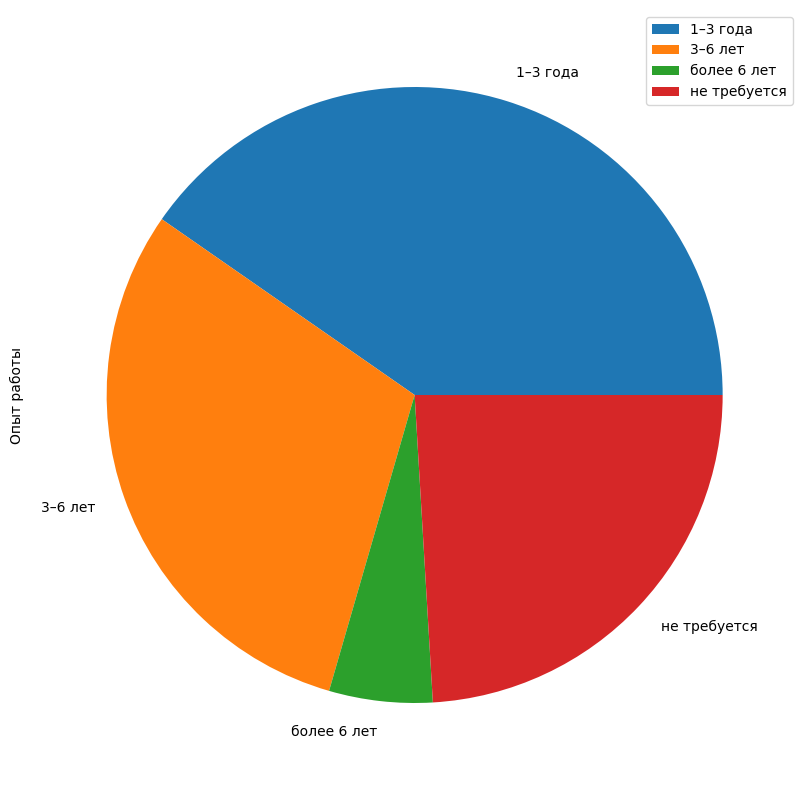

In [61]:
df.groupby("Опыт работы").agg({'Опыт работы': 'count'}).plot(kind="pie", subplots=True, figsize=(10, 10))

In [62]:
list_working_format = ["гибрид", "на месте работодателя", "разъездной", "удалённо"]

dict_working_format = {
    "Формат работы": [],
    "Количество": [],
}


for working_format in list_working_format:
    dict_working_format["Формат работы"].append(working_format)
    dict_working_format["Количество"].append(len(df[df["Формат работы"].str.contains(working_format)].index))

dict_working_format["Формат работы"].append("не указано")
dict_working_format["Количество"].append(len(df[df["Формат работы"] == "Not found"].index))

show_pie(dict_working_format["Формат работы"], dict_working_format["Количество"])